In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Remove unnecessary columns
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

# Convert diagnosis to numeric
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


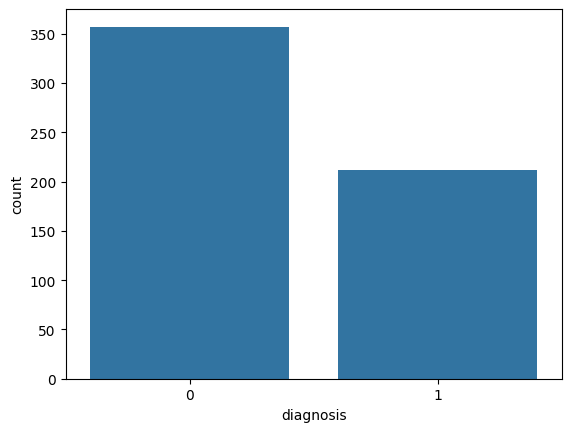

In [ ]:
sns.countplot(x='diagnosis', data=df)
plt.show()

In [ ]:
print(df['diagnosis'].value_counts())
print(df['diagnosis'].value_counts(normalize=True))

diagnosis
0    357
1    212
Name: count, dtype: int64
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


In [ ]:
import numpy as np

corr_matrix = df.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Drop these features:", to_drop)

# Drop them
df_reduced = df.drop(columns=to_drop)

Drop these features: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [ ]:
print("Original features:", df.shape[1])
print("Reduced features:", df_reduced.shape[1])

Original features: 31
Reduced features: 21


In [ ]:
corr_with_target = df.corr()['diagnosis'].sort_values(ascending=False)
print(corr_with_target)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

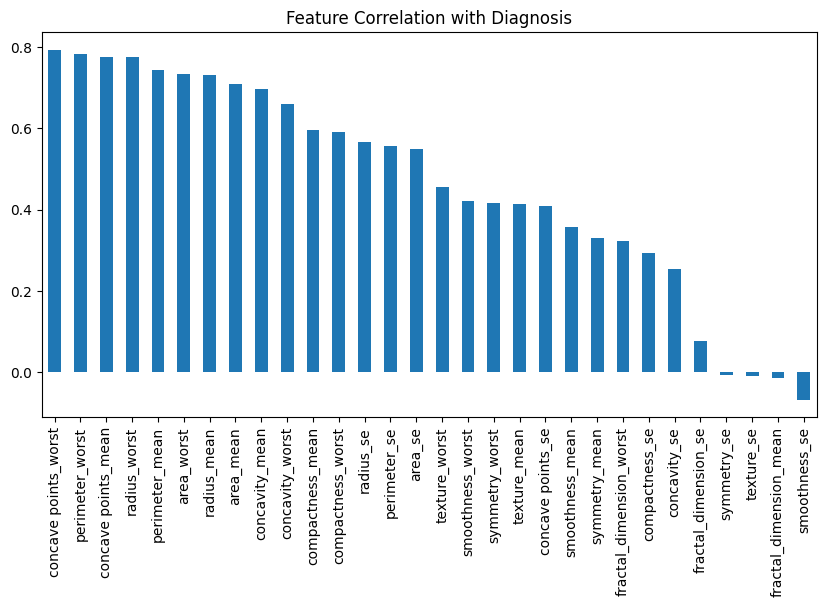

In [ ]:
import matplotlib.pyplot as plt

corr_with_target.drop('diagnosis').plot(kind='bar', figsize=(10,5))
plt.title("Feature Correlation with Diagnosis")
plt.show()

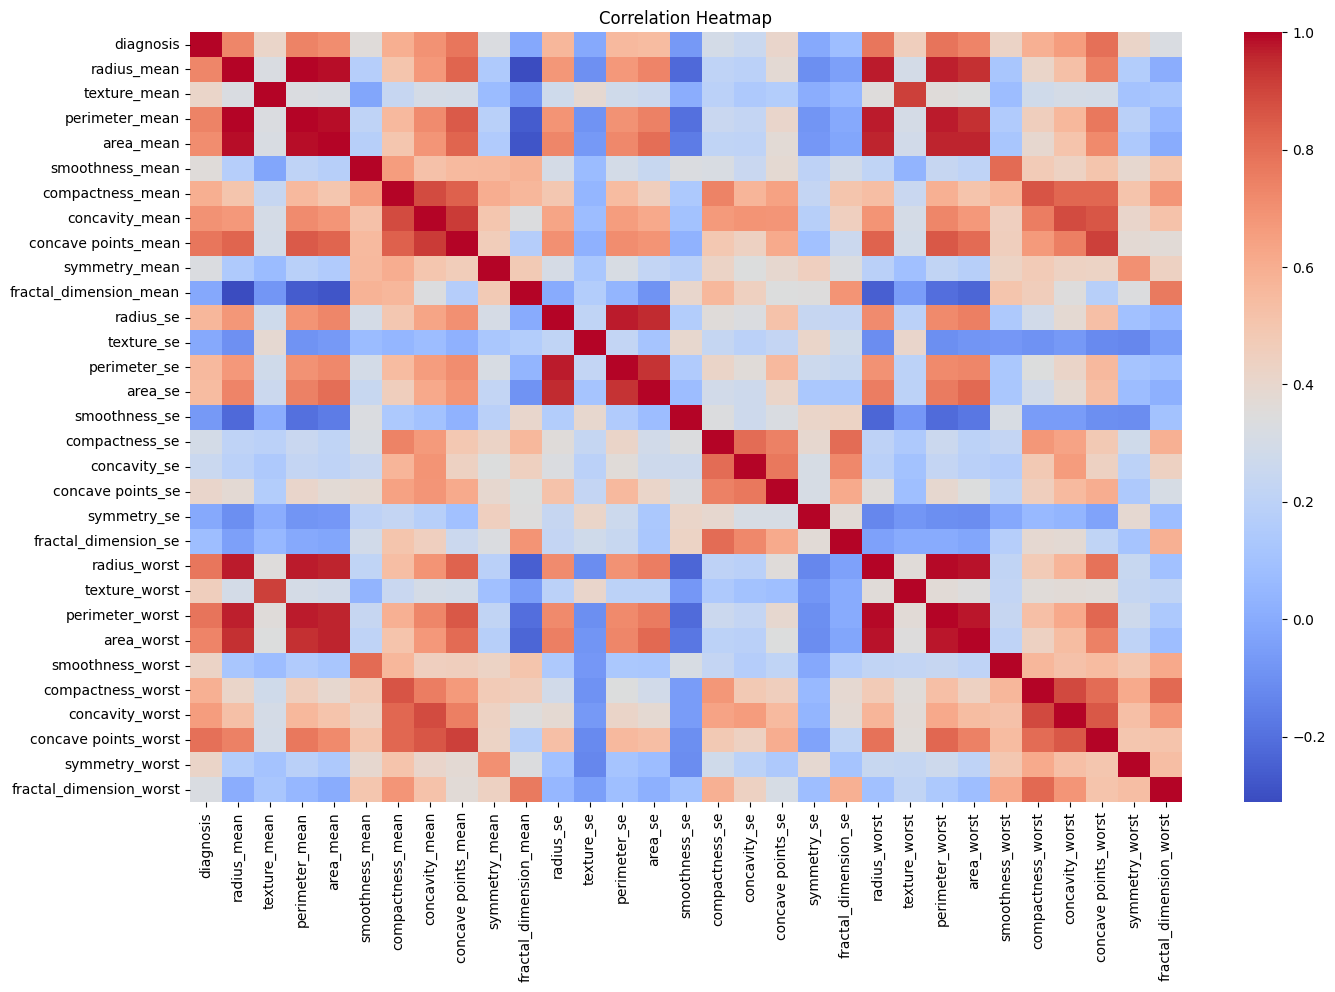

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
selected_features = [
    'concave points_worst',
    'radius_worst',
    'radius_mean',
    'concave points_mean',
    'concavity_mean',
    'texture_mean',
    'smoothness_mean'
]

In [ ]:
X = df[selected_features]
y = df['diagnosis']

In [ ]:
X.head()

,concave points_worst,radius_worst,radius_mean,concave points_mean,concavity_mean,texture_mean,smoothness_mean
0,0.2654,25.38,17.99,0.14710,0.3001,10.38,0.11840
1,0.1860,24.99,20.57,0.07017,0.0869,17.77,0.08474
2,0.2430,23.57,19.69,0.12790,0.1974,21.25,0.10960
3,0.2575,14.91,11.42,0.10520,0.2414,20.38,0.14250
4,0.1625,22.54,20.29,0.10430,0.1980,14.34,0.10030


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[69  2]
 [ 1 42]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
y_probs = model.predict_proba(X_test)[:, 1]

threshold = 0.3  # more sensitive to cancer

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95        71
           1       0.86      1.00      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.95      0.94      0.94       114



In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, make_scorer

In [ ]:
recall_scorer = make_scorer(recall_score, pos_label=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "class_weight": [None, "balanced"]
        }
    },

    "SVM": {
        "model": SVC(probability=True),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "class_weight": [None, "balanced"]
        }
    },

    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [None, 5, 10],
            "class_weight": [None, "balanced"]
        }
    }
}

In [ ]:
best_models = {}

for name, config in models.items():
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        config["model"],
        config["params"],
        scoring=recall_scorer,
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Params:", grid.best_params_)
    print("Best Recall (CV):", grid.best_score_)


Tuning LogisticRegression...
Best Params: {'C': 0.1, 'class_weight': 'balanced'}
Best Recall (CV): 0.9411764705882353

Tuning SVM...
Best Params: {'C': 10, 'class_weight': 'balanced', 'kernel': 'rbf'}
Best Recall (CV): 0.9470588235294117

Tuning RandomForest...
Best Params: {'class_weight': None, 'max_depth': None, 'n_estimators': 50}
Best Recall (CV): 0.9408199643493761


In [ ]:
from sklearn.metrics import classification_report

best_model = None
best_recall = 0

for name, model in best_models.items():
    y_pred = model.predict(X_test)

    recall = recall_score(y_test, y_pred)

    print(f"\n{name}")
    print("Recall (Malignant):", recall)
    print(classification_report(y_test, y_pred))

    if recall > best_recall:
        best_recall = recall
        best_model = model
        best_name = name


LogisticRegression
Recall (Malignant): 0.9767441860465116
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


SVM
Recall (Malignant): 0.9534883720930233
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


RandomForest
Recall (Malignant): 0.9302325581395349
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy              

In [ ]:
y_probs = best_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)

print("After Threshold Tuning:")
print(classification_report(y_test, y_pred_custom))

After Threshold Tuning:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        71
           1       0.86      1.00      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.95      0.94      0.94       114



In [ ]:
best_model
best_name

'LogisticRegression'

In [ ]:
y_probs = best_model.predict_proba(X_test)[:, 1]

threshold = 0.3  # you can tweak (0.3–0.4)

y_pred_final = (y_probs > threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[64  7]
 [ 0 43]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        71
           1       0.86      1.00      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.95      0.94      0.94       114



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Example: using your best_model (replace if needed)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# Train pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])

In [ ]:
import pickle

pickle.dump(pipeline, open("cancer_pipeline.pkl", "wb"))

In [ ]:
from google.colab import files

files.download("cancer_pipeline.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>